In [1]:
# Install dependencies
!pip install -q torch torchvision  torchaudio
!pip install -q opencv-python matplotlib
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

  Preparing metadata (setup.py) ... done


In [2]:
# Download SAM checkpoint
import os
checkpoint_path = "sam_vit_b_01ec64.pth"
if not os.path.exists(checkpoint_path):
  !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-02-20 08:34:54--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.108, 3.163.189.51, 3.163.189.96, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M  19.4MB/s    in 5.3s    

2026-02-20 08:34:59 (67.8 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [3]:
# Imports
import torch
import cv2
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from segment_anything import sam_model_registry, SamPredictor

In [41]:
# Load image from URL/ path
image_url = "/content/Screenshot 2026-02-20 140931.png"
image = Image.open(image_url).convert("RGB")
# image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")
image = np.array(image)

In [42]:
# Load SAM model
device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry["vit_b"](checkpoint = checkpoint_path)
sam.to(device = device)

predictor = SamPredictor(sam)
predictor.set_image(image)

In [53]:
# Provide a point prompt
# (x,y) coordinate on the object
# input_point = np.array([[380, 150]])  # try changing this
# input_label = np.array([1])  # 1 means foreground

input_box = np.array([250, 10, 580, 450])

input_point = np.array([
    [370, 80],   # her head
    [460, 200],  # her shoulder/sleeve
    [480, 320],  # her lower body/dress
])
input_label = np.array([1, 1, 1])

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)

# masks, scores, logits = predictor.predict(
#     point_coords = input_point,
#     point_labels = input_label,
#     multimask_output = True,
# )

In [54]:
# Vizualization helpers
def show_mask(mask, ax, color=[30/255, 144/255, 255/255, 0.6]):
  h, w = mask.shape[-2:]
  mask_image = mask.reshape(h, w, 1) * np.array(color).reshape(1, 1, 4)
  ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
  pos_points = coords[labels == 1]
  neg_points = coords[labels == 0]
  ax.scatter(pos_points[:, 0], pos_points[:, 1], color="green",
             marker="*", s=marker_size, edgecolor="white", linewidth=1.25)
  ax.scatter(neg_points[:, 0], neg_points[:, 1], color="red",
             marker="*", s=marker_size, edgecolor="white", linewidth=1.25)

Scores: [0.885123]
Best mask index: 0


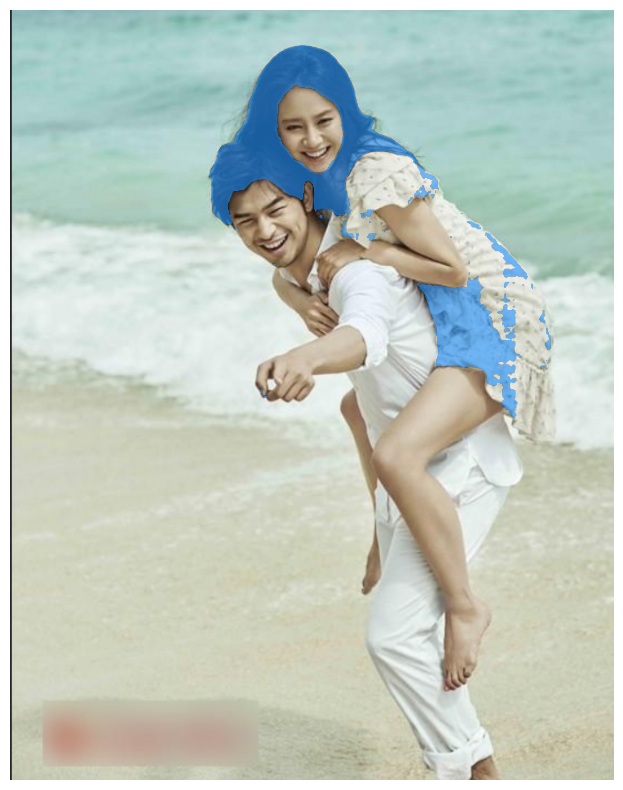

Mask confidence score: 0.885123


In [55]:
# Pick highest confidence mask FIRST
best_mask_idx = np.argmax(scores)
best_mask = masks[best_mask_idx]
print(f"Scores: {scores}")
print(f"Best mask index: {best_mask_idx}")

# Plot using BEST mask
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(best_mask, plt.gca())  # ← changed from masks[0] to best_mask
# show_points(input_point, input_label, plt.gca())
plt.axis("off")
plt.show()

print("Mask confidence score:", scores[best_mask_idx])  # ← fix this line

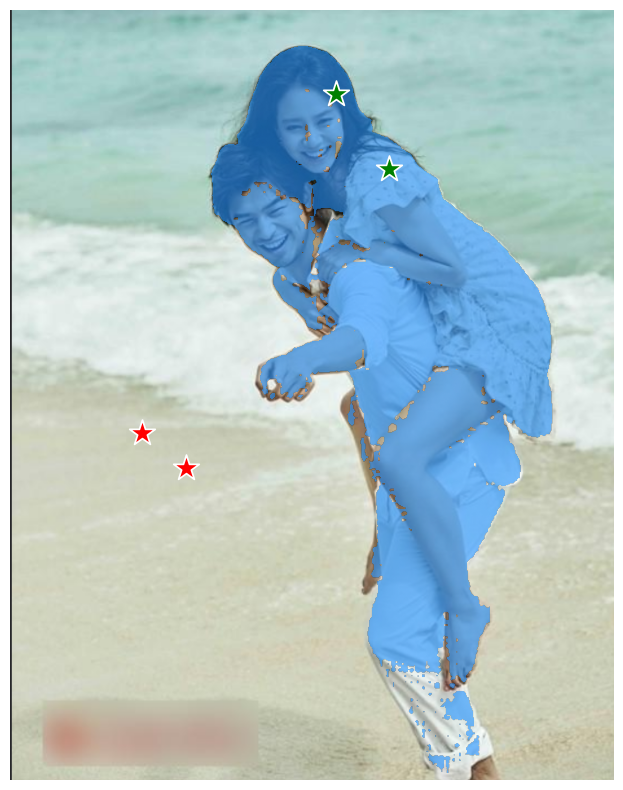

Scores: [0.8411556  0.9258787  0.88587594]


In [46]:
# # Plot results
# plt.figure(figsize=(10, 10))
# plt.imshow(image)
# show_mask(masks[0], plt.gca())
# show_points(input_point, input_label, plt.gca())
# plt.axis("off")
# plt.show()

# # Pick highest confidence mask
# best_mask_idx = np.argmax(scores)
# best_mask = masks[best_mask_idx]
# print(f"Scores: {scores}")  # check which mask is best

# # print("Mask confidence score:", scores[0])